In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Loading Dataset

In [ ]:
import pandas as pd

# Loading dataset
df = pd.read_csv('Titanic-Dataset.csv')

# Checking first few rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Missing values Analysis

In [ ]:
# Missing Values
print(df.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Basic Information
print(df.shape)
df.info()
print(df.describe())

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.

Survival Distribution

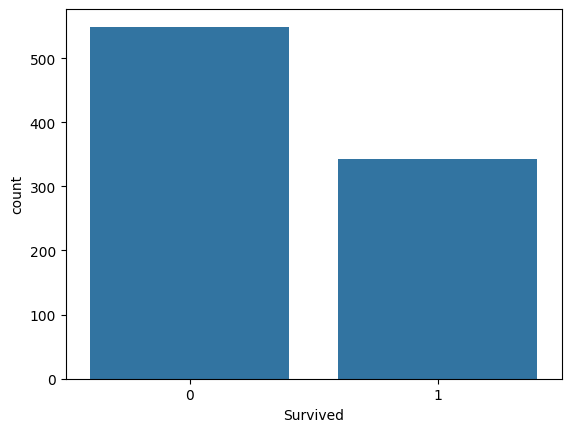

In [ ]:
# Survival Count
sns.countplot(x='Survived', data=df)
plt.show()

# Gender Analysis

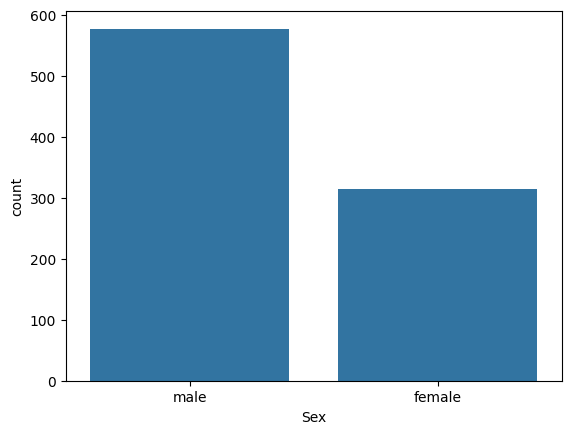

In [ ]:
# Gender Distribution
sns.countplot(x='Sex', data=df)
plt.show()


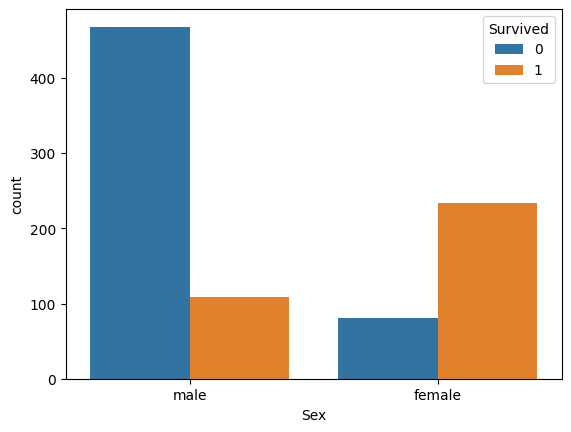

In [ ]:
# Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

# Passenger Class Analysis

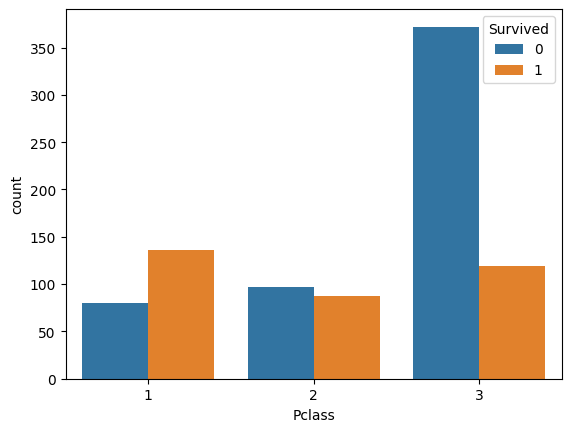

In [ ]:
# Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

Age Distribution

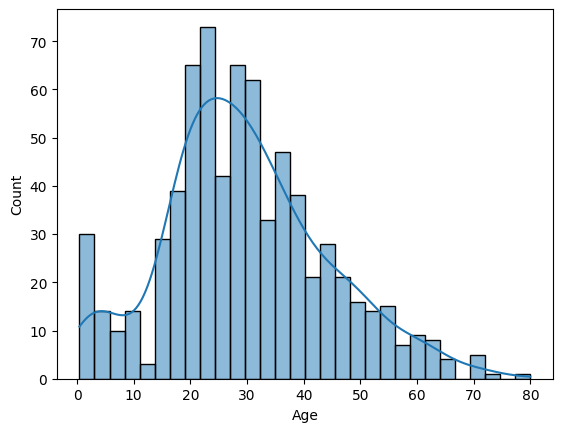

In [ ]:
# Age Distribution
sns.histplot(df['Age'], bins=30, kde=True)
plt.show()


Fare Wise Distribution

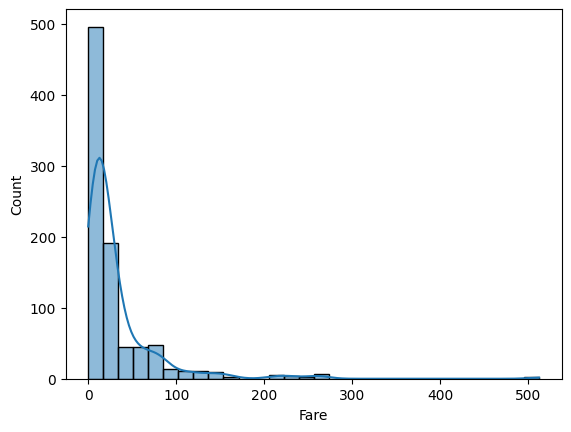

In [ ]:
# Fare Distribution
sns.histplot(df['Fare'], bins=30, kde=True)
plt.show()


Outlier Analysis with box

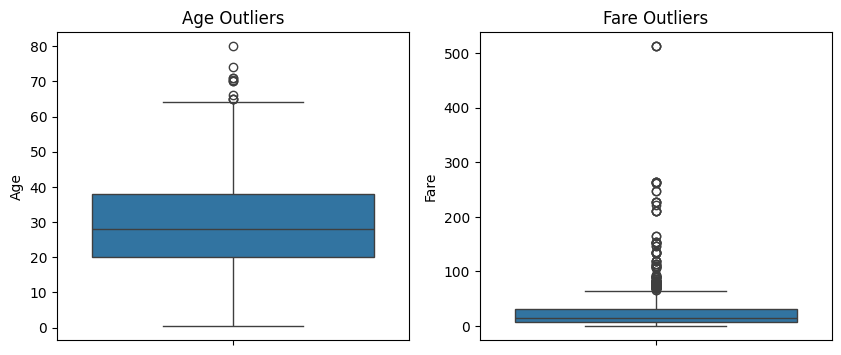

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(y=df['Age'])
plt.title('Age Outliers')

plt.subplot(1,2,2)
sns.boxplot(y=df['Fare'])
plt.title('Fare Outliers')

plt.show()

Correlation Analysis

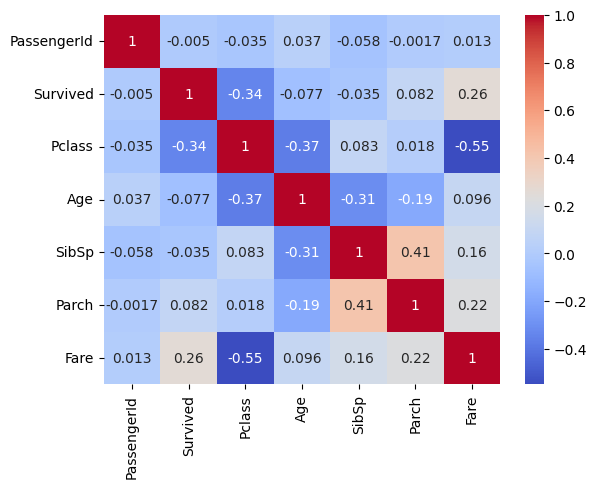

In [ ]:
# Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

In [ ]:
pd.crosstab(df['Pclass'], df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


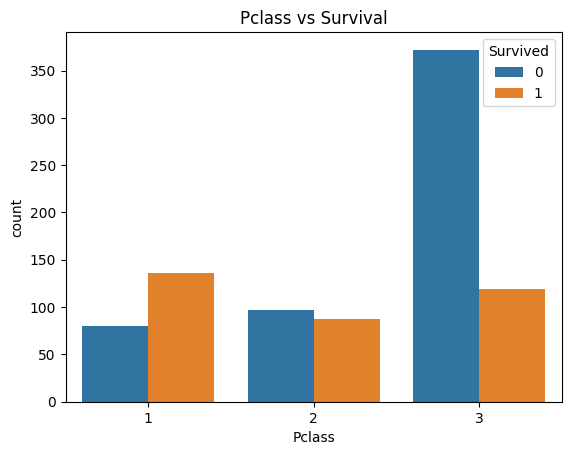

In [ ]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Pclass vs Survival")
plt.show()

In [ ]:
pd.crosstab(df['Sex'], df['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


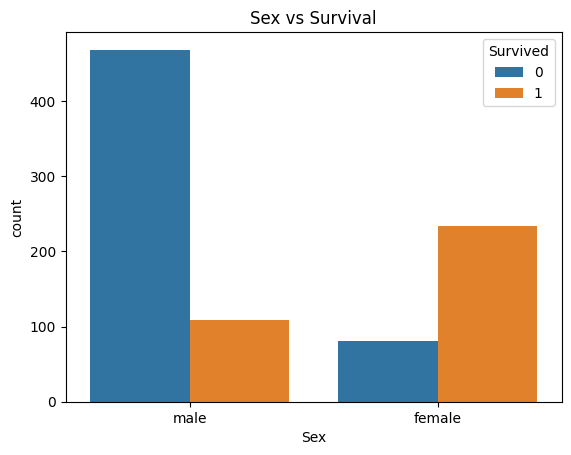

In [ ]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Sex vs Survival")
plt.show()

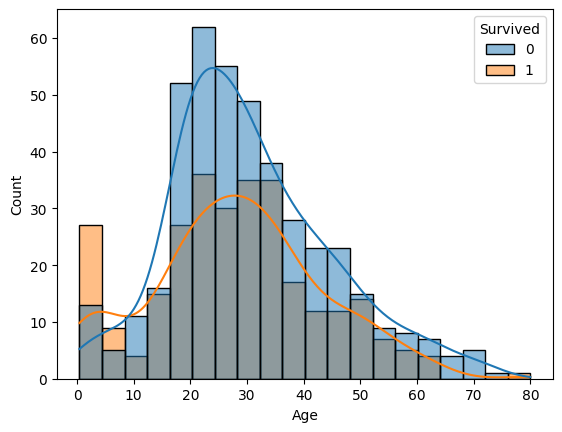

In [ ]:
sns.histplot(data=df,
             x='Age',
             hue='Survived',
             kde=True)

plt.show()

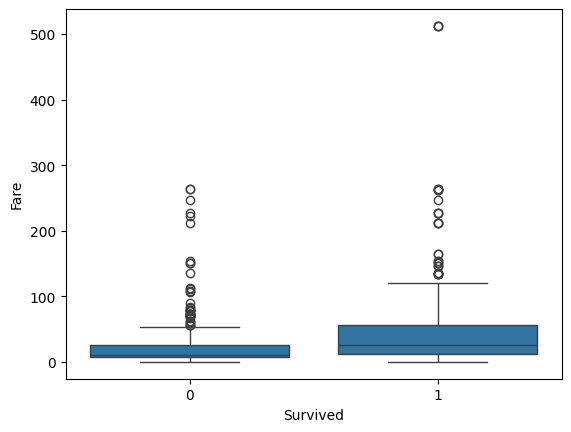

In [ ]:
sns.boxplot(x='Survived',
            y='Fare',
            data=df)

plt.show()

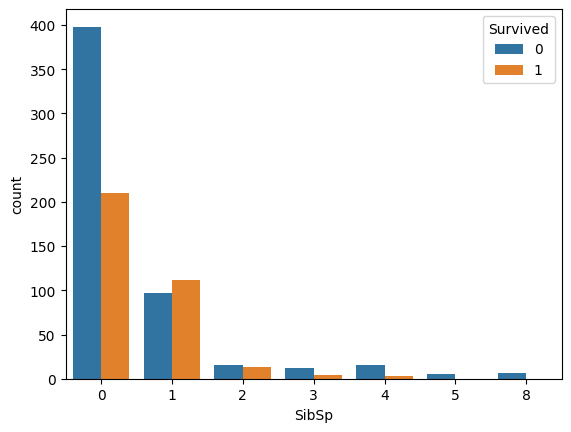

In [ ]:
sns.countplot(x='SibSp',
              hue='Survived',
              data=df)

plt.show()

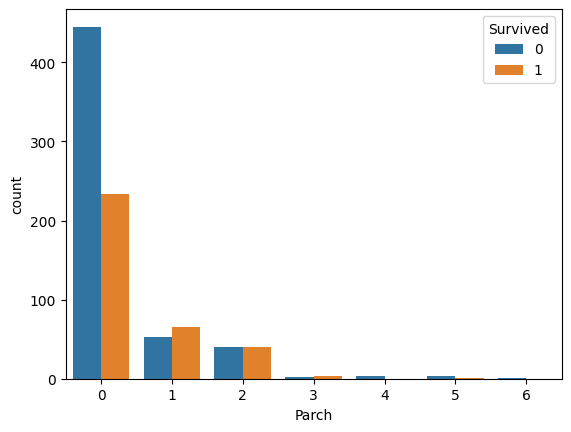

In [ ]:
sns.countplot(x='Parch',
              hue='Survived',
              data=df)

plt.show()

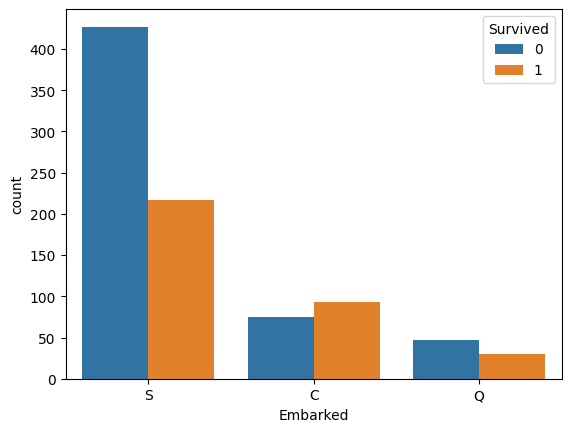

In [ ]:
sns.countplot(x='Embarked',
              hue='Survived',
              data=df)

plt.show()

In [ ]:
df.groupby('Sex')['Survived'].mean()*100

,Survived
Sex,
female,74.203822
male,18.890815


In [ ]:
df.groupby('Pclass')['Survived'].mean()*100

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


In [ ]:
corr = df.corr(numeric_only=True)

corr['Survived'].sort_values(ascending=False)

,Survived
Survived,1.000000
Fare,0.257307
Parch,0.081629
PassengerId,-0.005007
SibSp,-0.035322
Age,-0.077221
Pclass,-0.338481


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

le = LabelEncoder()

df_ml['Sex'] = le.fit_transform(df_ml['Sex'])

df_ml['Embarked'] = le.fit_transform(
    df_ml['Embarked'].astype(str)
)

In [ ]:
features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]

X = df_ml[features]
y = df_ml['Survived']

In [ ]:
X['Age'] = X['Age'].fillna(X['Age'].median())

/tmp/ipykernel_2333/1341152632.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Age'] = X['Age'].fillna(X['Age'].median())


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

    Feature  Importance
5      Fare    0.274750
1       Sex    0.261698
2       Age    0.258267
0    Pclass    0.087240
3     SibSp    0.045938
4     Parch    0.038050
6  Embarked    0.034056


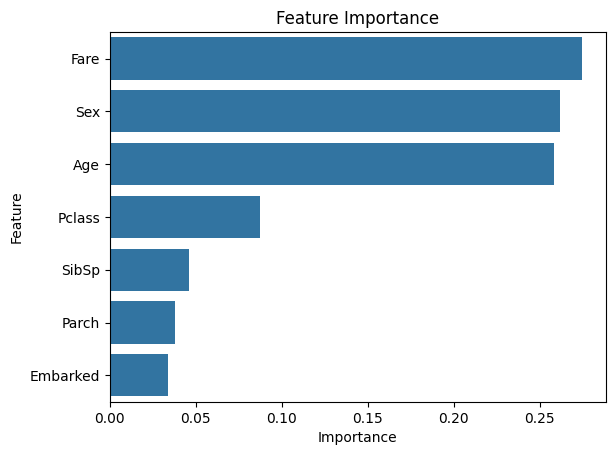

In [ ]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

In [ ]:
features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

le = LabelEncoder()

df_ml['Sex'] = le.fit_transform(df_ml['Sex'])
df_ml['Embarked'] = le.fit_transform(df_ml['Embarked'].astype(str))

In [ ]:
df_ml['Age'] = df_ml['Age'].fillna(df_ml['Age'].median())

In [ ]:
X = df_ml[features]
y = df_ml['Survived']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

pred = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8100558659217877


In [ ]:
lr_acc = accuracy_score(y_test, pred)
print(lr_acc)

0.8100558659217877


KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8044692737430168


In [ ]:
knn_acc = accuracy_score(y_test, pred)
print(knn_acc)

0.8044692737430168


Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.7988826815642458


In [ ]:
dt_acc = accuracy_score(y_test, pred)
print(dt_acc)

0.7988826815642458


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8212290502793296


In [ ]:
rf_acc = accuracy_score(y_test, pred)
print(rf_acc)

0.8212290502793296


SVM (Support Vector Machine)

In [ ]:
from sklearn.svm import SVC

svm_linear = SVC(
    kernel='linear'
)

svm_linear.fit(X_train_scaled, y_train)

pred = svm_linear.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.7821229050279329


In [ ]:
svm_linear_acc = accuracy_score(y_test, pred)

SVM (RBF)

In [ ]:
svm_rbf = SVC(
    kernel='rbf'
)

svm_rbf.fit(X_train_scaled, y_train)

pred = svm_rbf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8156424581005587


In [ ]:
svm_rbf_acc = accuracy_score(y_test, pred)

Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

pred = nb.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.776536312849162


In [ ]:
nb_acc = accuracy_score(y_test, pred)

Gradiant Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train, y_train)

pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8100558659217877


In [ ]:
gb_acc = accuracy_score(y_test, pred)

XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8156424581005587


In [ ]:
xgb_acc = accuracy_score(y_test, pred)

In [ ]:
models = [
    'Logistic Regression',
    'KNN',
    'Decision Tree',
    'Random Forest',
    'SVM Linear',
    'SVM RBF',
    'Naive Bayes',
    'Gradient Boosting',
    'XGBoost'
]

accuracies = [
    lr_acc,
    knn_acc,
    dt_acc,
    rf_acc,
    svm_linear_acc,
    svm_rbf_acc,
    nb_acc,
    gb_acc,
    xgb_acc
]

print(len(models))
print(len(accuracies))

9
9


In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'SVM (Linear)',
        'SVM (RBF)',
        'Naive Bayes',
        'Gradient Boosting',
        'XGBoost'
    ],
    'Accuracy': [
        0.8101,
        0.8045,
        0.7989,
        0.8212,
        0.7821,
        0.8156,
        0.7765,
        0.8100,
        0.8156,
    ]
})

results = results.sort_values(by='Accuracy', ascending=False)

print(results)

                 Model  Accuracy
3        Random Forest    0.8212
8              XGBoost    0.8156
5            SVM (RBF)    0.8156
0  Logistic Regression    0.8101
7    Gradient Boosting    0.8100
1                  KNN    0.8045
2        Decision Tree    0.7989
4         SVM (Linear)    0.7821
6          Naive Bayes    0.7765


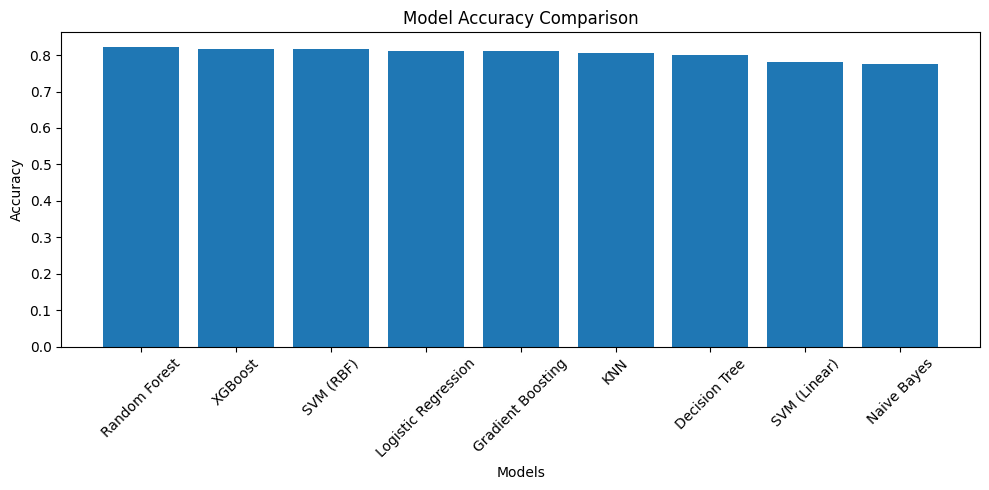

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(results['Model'], results['Accuracy'])

plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

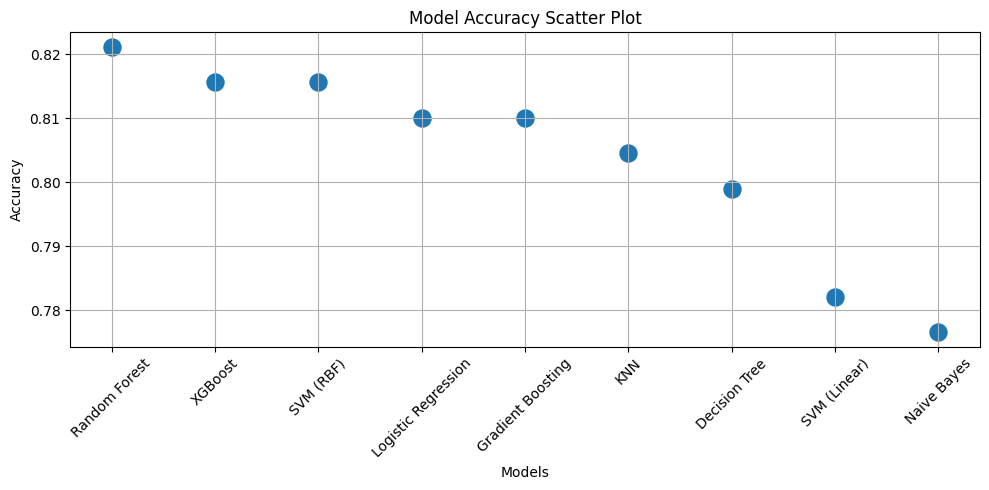

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(
    results['Model'],
    results['Accuracy'],
    s=150
)

plt.title('Model Accuracy Scatter Plot')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

Models and Accuracies

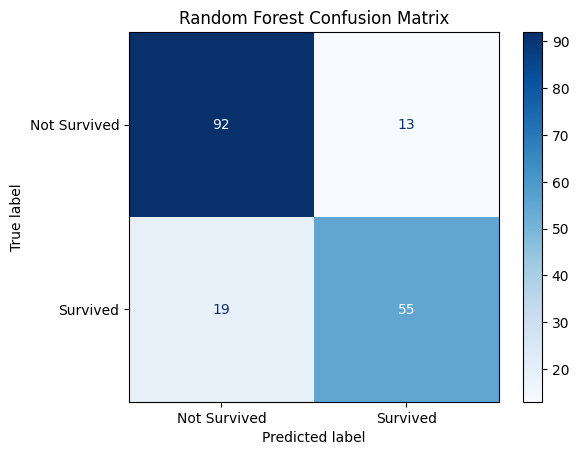

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred_rf = rf.predict(X_test)

cm = confusion_matrix(y_test, pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Survived', 'Survived']
)

disp.plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

pred_rf = rf.predict(X_test)

cm = confusion_matrix(y_test, pred_rf)

print(cm)

[[92 13]
 [19 55]]


#Hyperparameter tuning (Random Forest)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 5, 'n_estimators': 100}
0.828592534226337


#Hyperparameter tuning (SVM)

In [ ]:
from sklearn.svm import SVC

params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid = GridSearchCV(
    SVC(),
    params,
    cv=5
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)

{'C': 1, 'kernel': 'rbf'}


#Hyperparameter Tuning (Decision Tree)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

params = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 3, 'min_samples_split': 2}


#Hpperparameter Tuning (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

params = {
    'n_neighbors': [3, 5, 7, 9]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    params,
    cv=5
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)

{'n_neighbors': 7}


#Hyperparameter Tuning (Logistic Regression)

In [ ]:
from sklearn.linear_model import LogisticRegression

params = {
    'C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    params,
    cv=5
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)

{'C': 0.01}


#Hyperparameter Tuning (XG Boost)

In [ ]:
from xgboost import XGBClassifier

params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7]
}

grid = GridSearchCV(
    XGBClassifier(random_state=42),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


#Cross Validation (cv)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5
)

print(scores)
print(scores.mean())

[0.8041958  0.74825175 0.81690141 0.77464789 0.83098592]
0.7949965527430315
